In [3]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *

In [4]:
dataframes = []
for i in range(1, 11):
    file_path = f'/Users/kellyhui/Downloads/KH_RBG_onetimeread_030726_PF4_P0_{i}.csv'
    df = pd.read_csv(f'{file_path}') 
    df = clean_and_transpose(df, 24, 122).dropna().transpose()
    df = df.reset_index()
    df.columns = ['Well', 'OD']
    dataframes.append(df)

In [5]:
#make master dataframe 
def tidy_plate(df, plate_num):
    df.columns = ['Well', 'OD']

    # Extract BioRep and column number
    df['BioRep'] = df['Well'].str[0]
    df['Col'] = df['Well'].str[1:].astype(int)

    # Map column number to dose
    def col_to_dose(col):
        if col in [1,2,3]:
            return 0
        elif col in [4,5,6]:
            return 1e4
        elif col in [7,8,9]:
            return 1e6
        elif col in [10,11,12]:
            return 1e8
        else:
            return np.nan

    df['Dose'] = df['Col'].apply(col_to_dose)
    df = df.sort_values(by=['BioRep', 'Dose', 'Col']).reset_index(drop=True)

    df['Plate'] = plate_num

    return df[['Plate','BioRep','Dose','Col','OD']]

#run all 10 plates into 1 df
tidy_all = pd.concat([tidy_plate(df, i+1) for i, df in enumerate(dataframes)], ignore_index=True)

tidy_all

,Plate,BioRep,Dose,Col,OD
0,1,A,0.0,1,0.3577
1,1,A,0.0,2,0.3305
2,1,A,0.0,3,0.3249
3,1,A,10000.0,4,0.3468
4,1,A,10000.0,5,0.3320
...,...,...,...,...,...
955,10,H,1000000.0,8,0.3198
956,10,H,1000000.0,9,0.3111
957,10,H,100000000.0,10,0.3165
958,10,H,100000000.0,11,0.2970


In [6]:
#group plate, biol rep, and dose
bio_rep_mean = tidy_all.groupby(['Plate','BioRep','Dose'], as_index=False)['OD'].mean()
bio_rep_mean

,Plate,BioRep,Dose,OD
0,1,A,0.0,0.337700
1,1,A,10000.0,0.335867
2,1,A,1000000.0,0.338633
3,1,A,100000000.0,0.331567
4,1,B,0.0,0.464633
...,...,...,...,...
315,10,G,100000000.0,0.529200
316,10,H,0.0,0.295567
317,10,H,10000.0,0.318933
318,10,H,1000000.0,0.313333


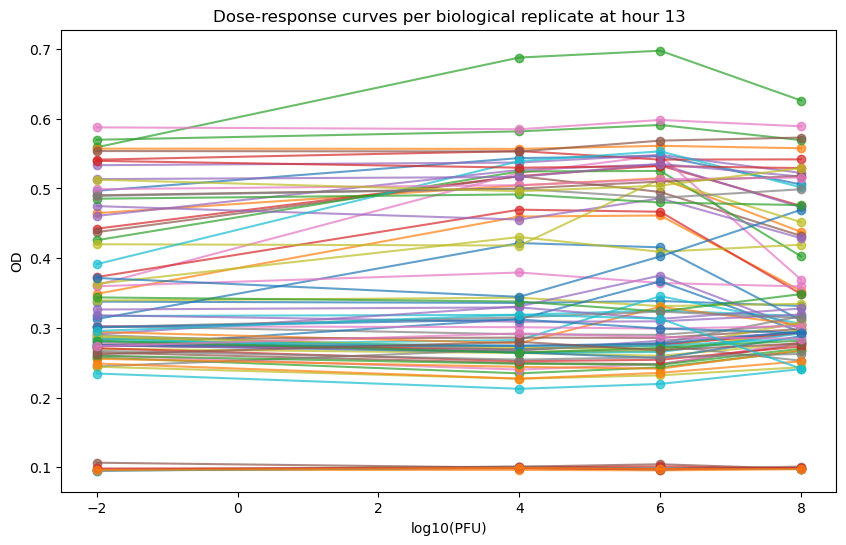

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Make a column for plotting log10 dose; replace 0 with small number
bio_rep_mean['Dose_plot'] = bio_rep_mean['Dose'].replace(0, 0.01)  # 0 dose -> 0.01

for plate in bio_rep_mean['Plate'].unique():
    plate_df = bio_rep_mean[bio_rep_mean['Plate']==plate]

    for bio in plate_df['BioRep'].unique():
        bio_df = plate_df[plate_df['BioRep']==bio]
        plt.plot(np.log10(bio_df['Dose_plot']), bio_df['OD'], marker='o', alpha=0.7)

plt.xlabel('log10(PFU)')
plt.ylabel('OD')
plt.title('Dose-response curves per biological replicate at hour 13')

plt.show()

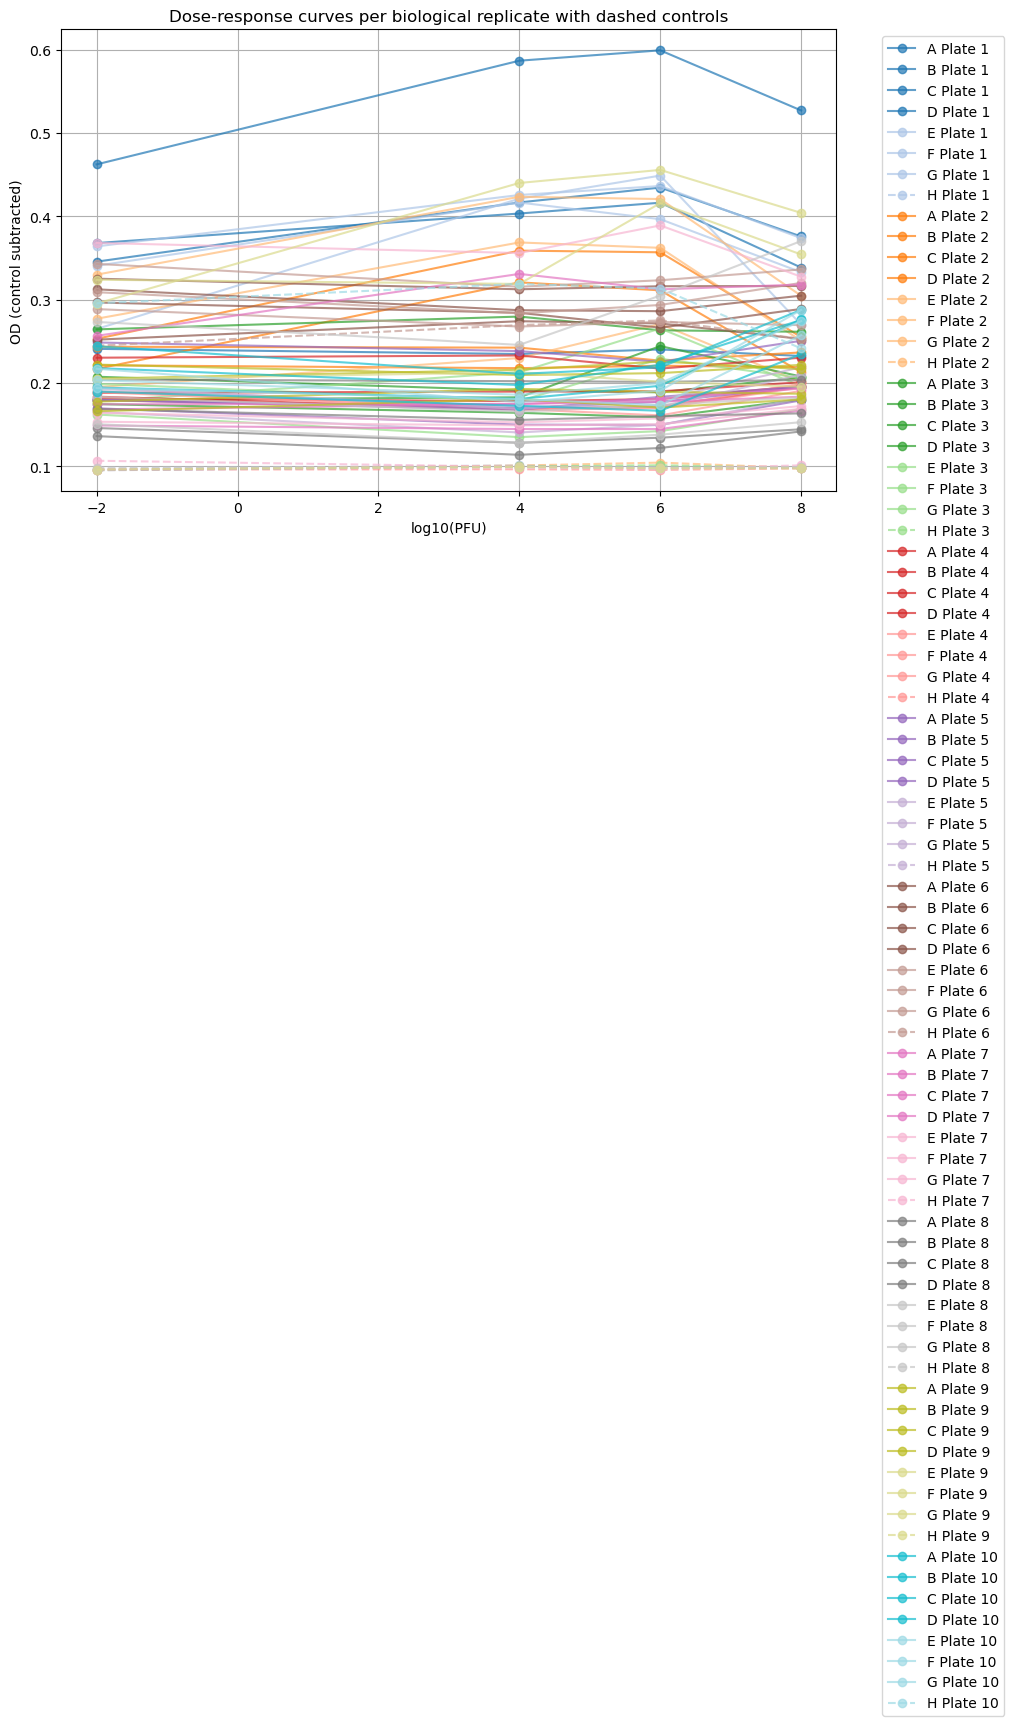

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# Get all unique lines you will plot (plate × BioRep)
lines = [(plate, bio) for plate in bio_rep_mean['Plate'].unique()
                        for bio in bio_rep_mean['BioRep'].unique()]

# Generate a colormap for all lines (so control can share a color if you like)
colors = plt.cm.tab20(np.linspace(0,1,len(lines)))

for i, (plate, bio) in enumerate(lines):
    plate_df = bio_rep_mean[(bio_rep_mean['Plate']==plate) & (bio_rep_mean['BioRep']==bio)]
    dose = plate_df['Dose_plot']
    od = plate_df['OD']

    # Use a dashed line for control (BioRep H)
    if bio == 'H':
        plt.plot(np.log10(dose), od, marker='o', linestyle='--', color=colors[i], alpha=0.7, label=f'{bio} Plate {plate}')
    else:
        # Subtract control for other BioReps
        control_df = bio_rep_mean[(bio_rep_mean['Plate']==plate) & (bio_rep_mean['BioRep']=='H')].set_index('Dose_plot')['OD']
        od_corrected = od.values - control_df.reindex(dose, fill_value=0)
        plt.plot(np.log10(dose), od_corrected, marker='o', linestyle='-', color=colors[i], alpha=0.7, label=f'{bio} Plate {plate}')

plt.xlabel('log10(PFU)')
plt.ylabel('OD (control subtracted)')
plt.title('Dose-response curves per biological replicate with dashed controls')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

/var/folders/zr/1sf51yw57tz981pxfk3xyts40000gn/T/ipykernel_79039/894465280.py:25: RuntimeWarning: divide by zero encountered in log10
  x_log = np.where(x_vals == 0, 0, np.log10(x_vals))


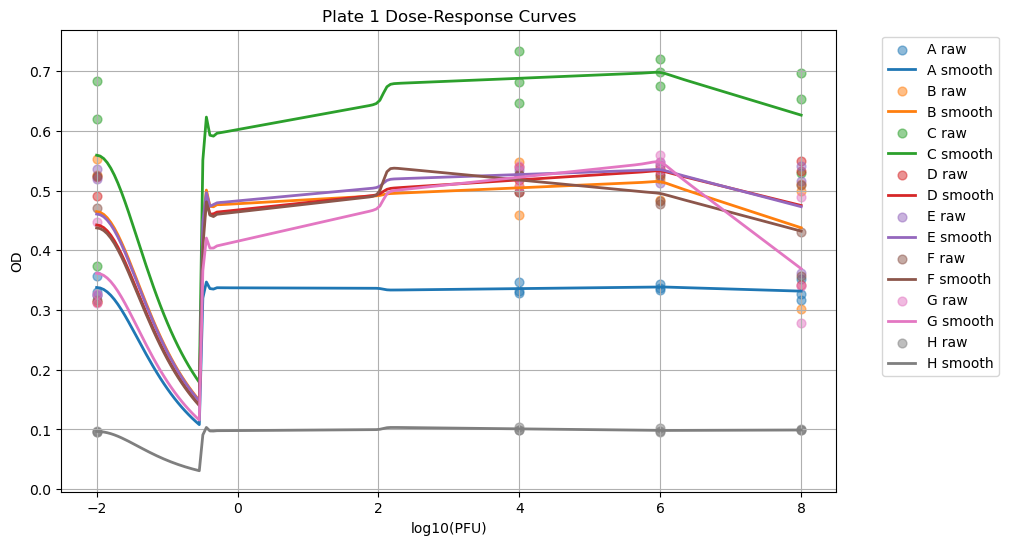

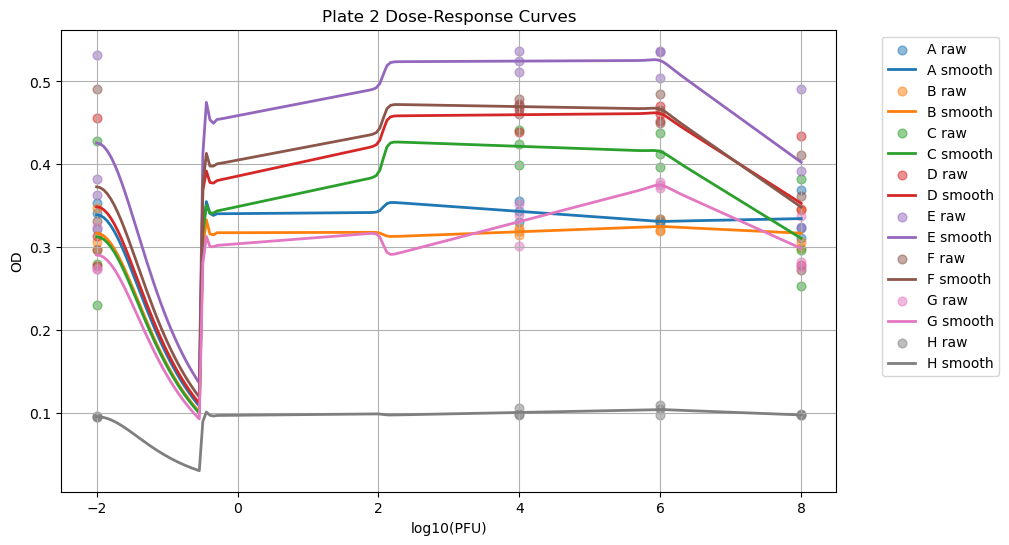

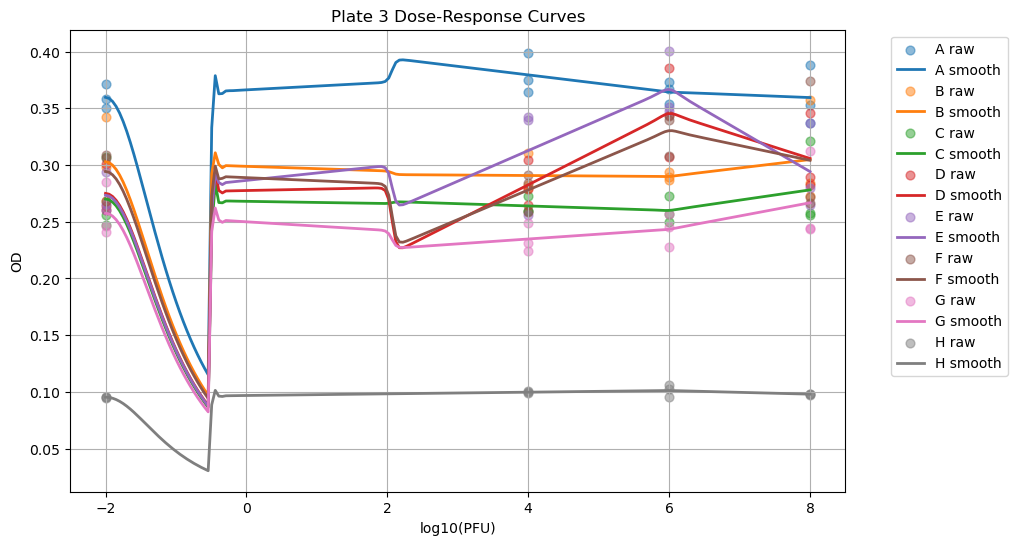

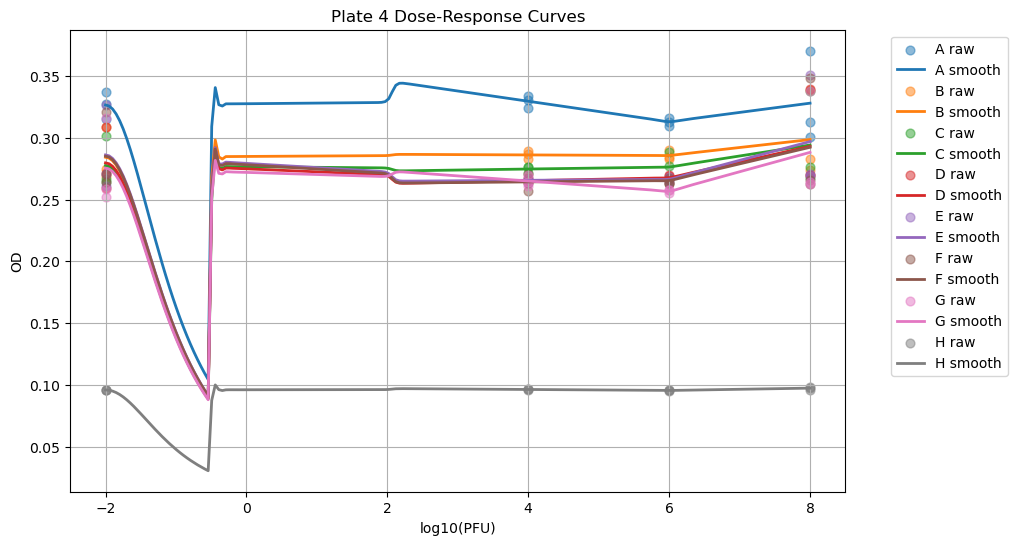

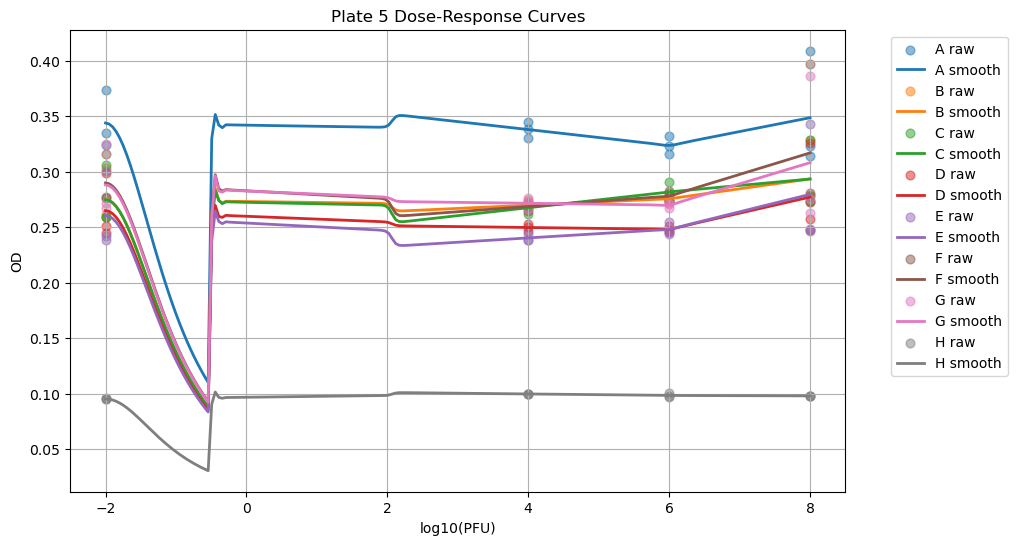

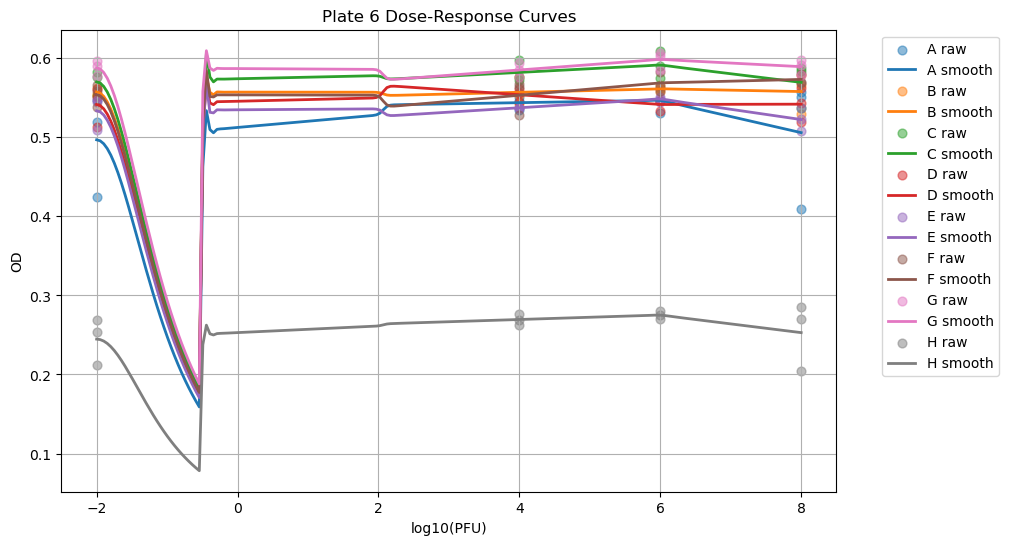

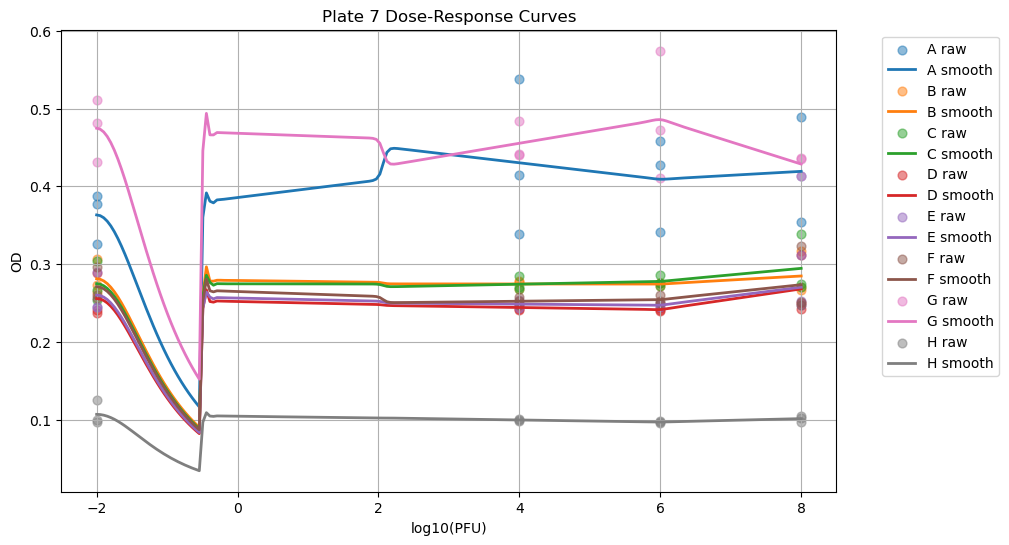

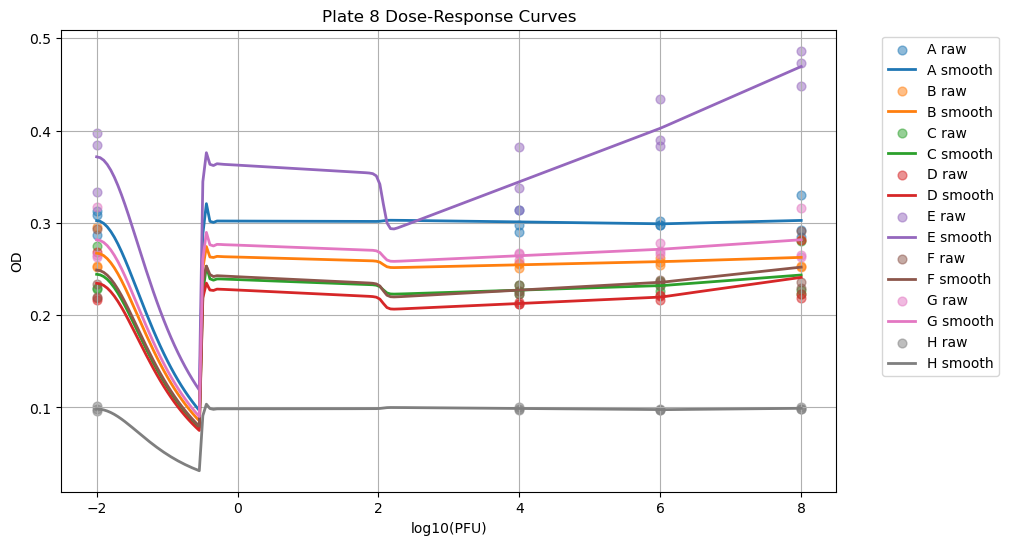

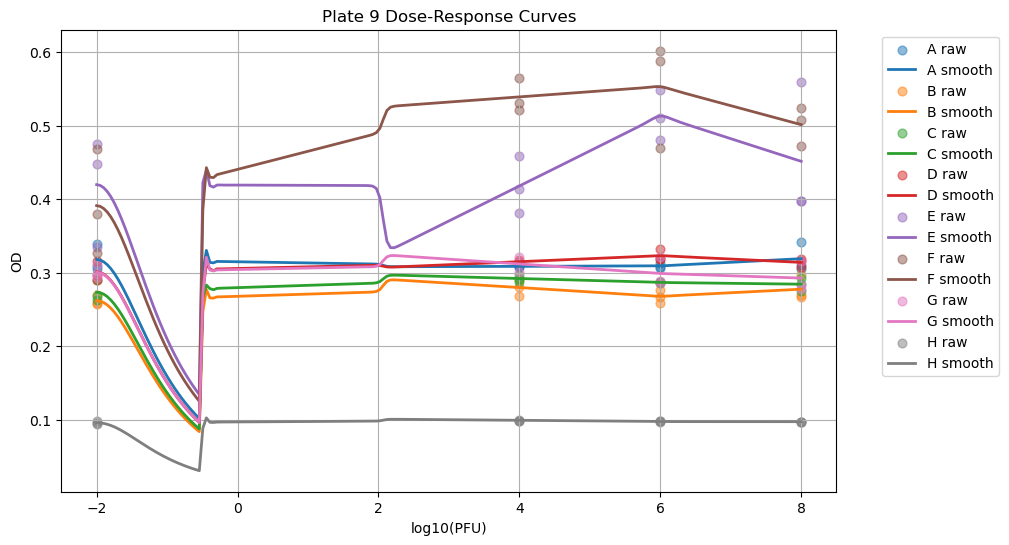

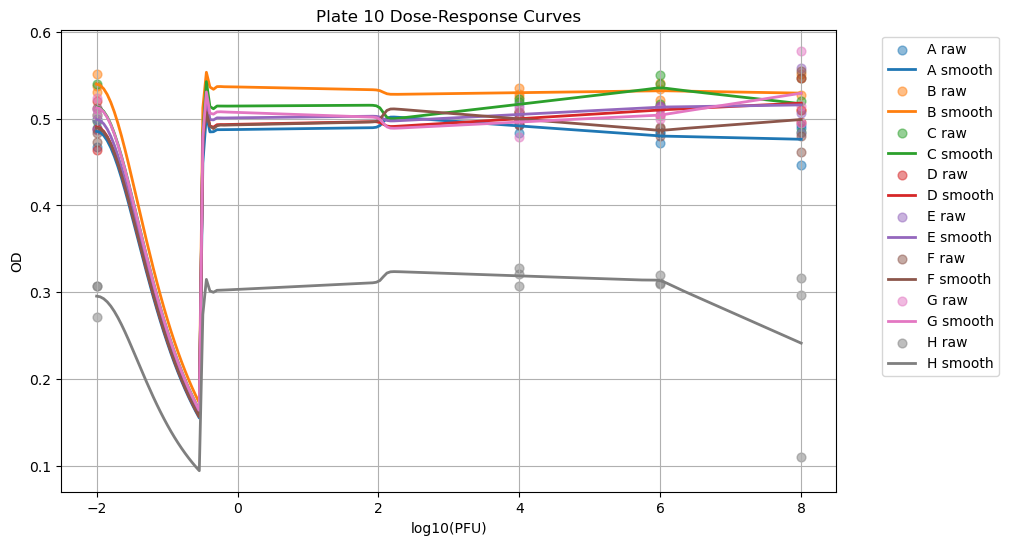

,A,B,C,D,E,F,G,H
1,-1.296482,-1.346734,-1.497487,-1.447236,-1.396985,-1.447236,-1.698492,-1.346734
2,-1.296482,-1.346734,-1.547739,-1.547739,-1.447236,-1.497487,-1.497487,-1.346734
3,-1.346734,-1.296482,-1.346734,-1.497487,-1.547739,-1.396985,-1.296482,-1.346734
4,-1.346734,-1.346734,-1.346734,-1.296482,-1.296482,-1.296482,-1.296482,-1.296482
5,-1.296482,-1.346734,-1.346734,-1.296482,-1.346734,-1.346734,-1.346734,-1.346734
6,-1.346734,-1.296482,-1.346734,-1.346734,-1.346734,-1.346734,-1.296482,-1.396985
7,-1.447236,-1.346734,-1.346734,-1.296482,-1.296482,-1.296482,-1.296482,-1.296482
8,-1.346734,-1.296482,-1.296482,-1.296482,2.271357,-1.296482,-1.296482,-1.346734
9,-1.296482,-1.346734,-1.346734,-1.346734,-1.447236,-1.597990,-1.346734,-1.346734
10,-1.296482,-1.296482,-1.346734,-1.346734,-1.346734,-1.296482,-1.296482,-1.346734


In [15]:
#IC50 vals
from scipy.interpolate import interp1d
from statsmodels.nonparametric.kernel_regression import KernelReg
from tools import *

bio_reps = tidy_all['BioRep'].unique()
plates = tidy_all['Plate'].unique()

# Table to store IC50 values
ic50_table = pd.DataFrame(index=plates, columns=bio_reps, dtype=float)

for plate in plates:
    plate_df = tidy_all[tidy_all['Plate'] == plate]

    plt.figure(figsize=(10,6))
    plt.title(f'Plate {plate} Dose-Response Curves')
    
    for bio in bio_reps:
        bio_df = plate_df[plate_df['BioRep'] == bio]

        # Use technical replicates as they are
        x_vals = bio_df['Dose'].values
        y_vals = bio_df['OD'].values

        x_log = np.where(x_vals == 0, 0, np.log10(x_vals))
        if len(x_vals) == 0 or len(y_vals) == 0:
            continue
            
        # Log10 transform dose for smoothing
        x_log = np.log10(np.where(x_vals==0, 1e-2, x_vals))
        
        # Fit local linear kernel regression
        kr = KernelReg(endog=y_vals, exog=x_log, var_type='c', reg_type='ll', bw=[0.5])
        x_grid = np.linspace(x_log.min(), x_log.max(), 200)
        y_pred_grid, _ = kr.fit(x_grid)

        # Half-max OD
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2

        # Find IC50: x where smoothed OD crosses half-max
        idx = np.argmin(np.abs(y_pred_grid - half_max))
        ic50_log = x_grid[idx]
        #ic50 = 10**ic50_log  # back-transform to PFU
        ic50_table.loc[plate, bio] = ic50_log

        # Plot raw points
        plt.scatter(x_log, y_vals, label=f'{bio} raw', alpha=0.5, s=40)

        # Plot smoothed curve
        plt.plot(x_grid, y_pred_grid, lw=2, label=f'{bio} smooth')
    
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()

ic50_table

In [16]:
# Flatten all IC50 values into a single array
ic50_values = ic50_table.values.flatten()
ic50_values

array([-1.29648241, -1.34673367, -1.49748744, -1.44723618, -1.39698492,
       -1.44723618, -1.69849246, -1.34673367, -1.29648241, -1.34673367,
       -1.54773869, -1.54773869, -1.44723618, -1.49748744, -1.49748744,
       -1.34673367, -1.34673367, -1.29648241, -1.34673367, -1.49748744,
       -1.54773869, -1.39698492, -1.29648241, -1.34673367, -1.34673367,
       -1.34673367, -1.34673367, -1.29648241, -1.29648241, -1.29648241,
       -1.29648241, -1.29648241, -1.29648241, -1.34673367, -1.34673367,
       -1.29648241, -1.34673367, -1.34673367, -1.34673367, -1.34673367,
       -1.34673367, -1.29648241, -1.34673367, -1.34673367, -1.34673367,
       -1.34673367, -1.29648241, -1.39698492, -1.44723618, -1.34673367,
       -1.34673367, -1.29648241, -1.29648241, -1.29648241, -1.29648241,
       -1.29648241, -1.34673367, -1.29648241, -1.29648241, -1.29648241,
        2.27135678, -1.29648241, -1.29648241, -1.34673367, -1.29648241,
       -1.34673367, -1.34673367, -1.34673367, -1.44723618, -1.59

Text(0.5, 0, 'IC50 (PFU)')

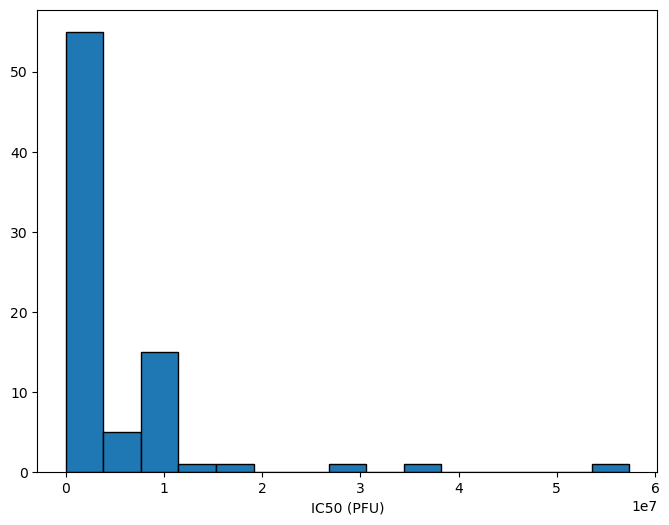

In [183]:
plt.figure(figsize=(8,6))
plt.hist(ic50_values, bins=15, edgecolor='black')
plt.xlabel('IC50 (PFU)')

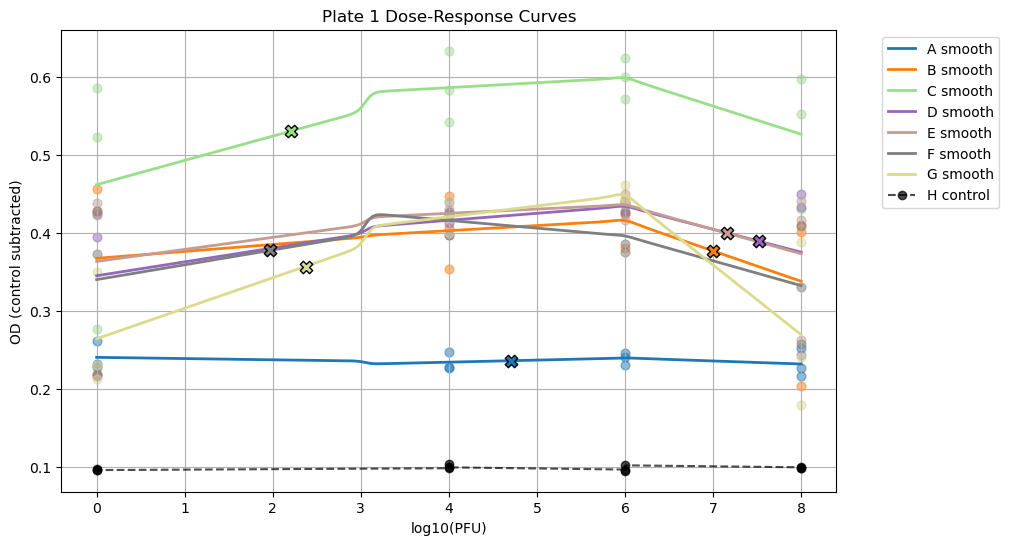

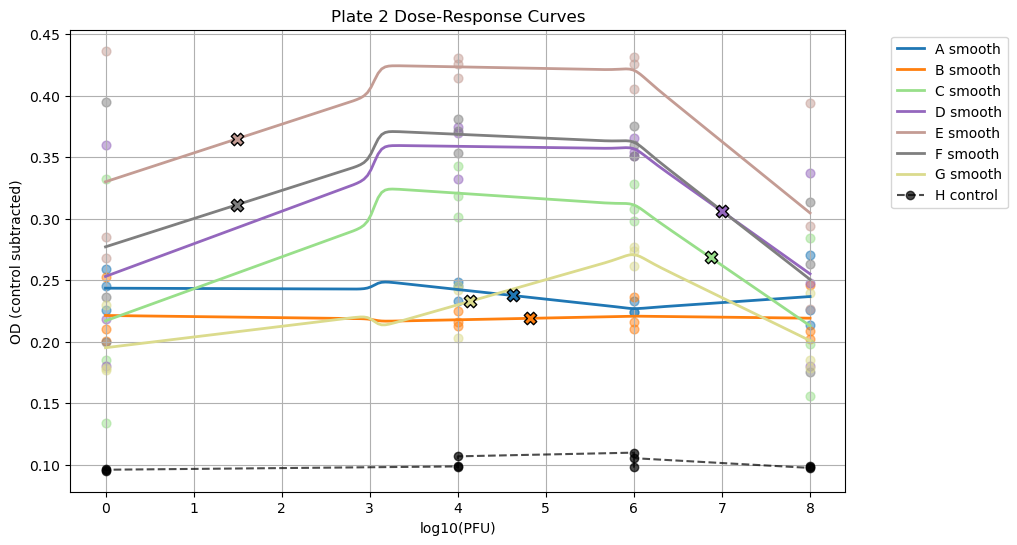

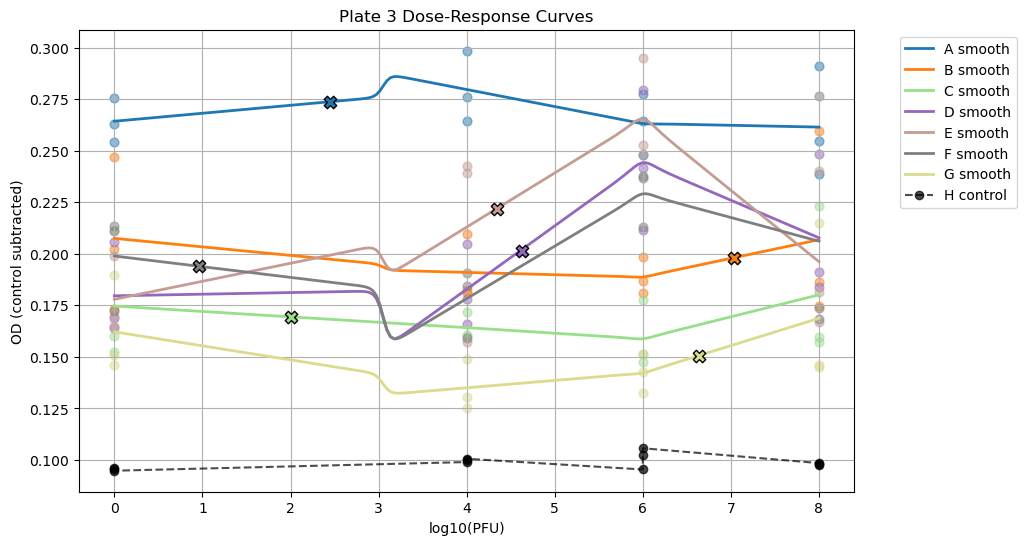

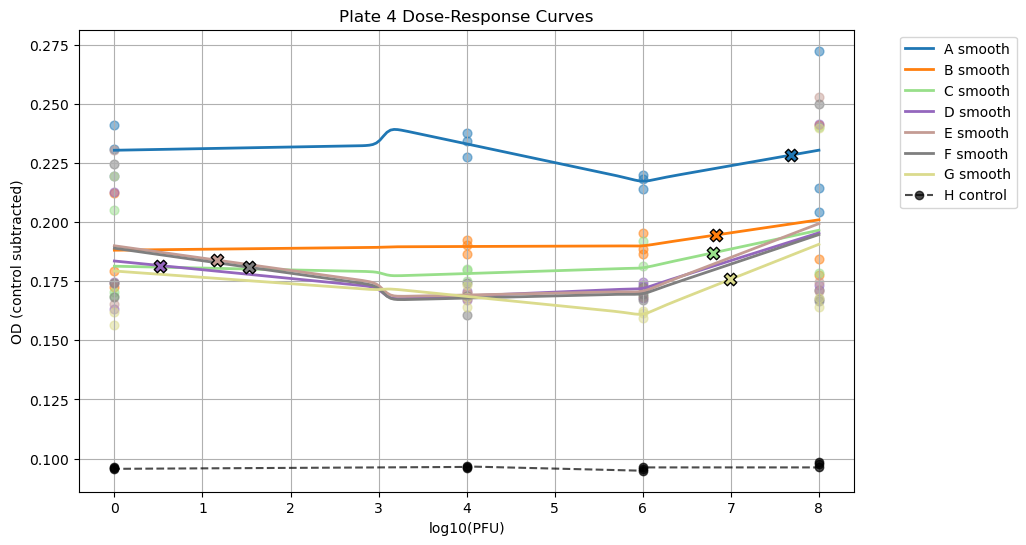

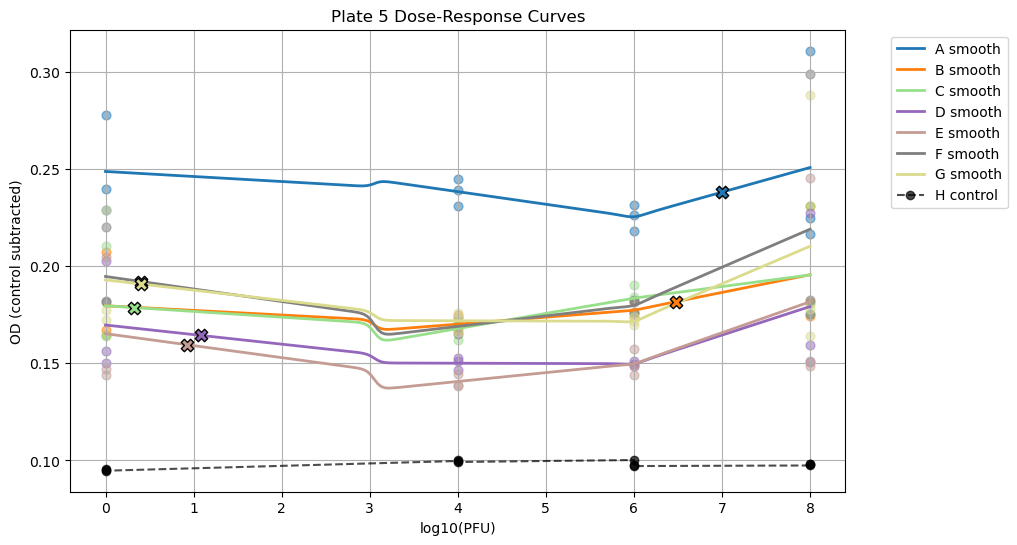

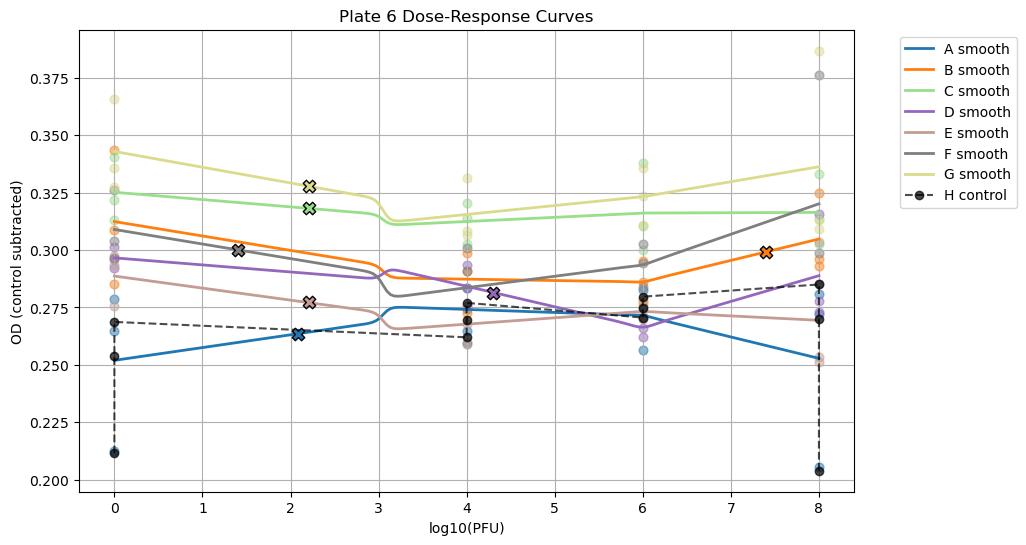

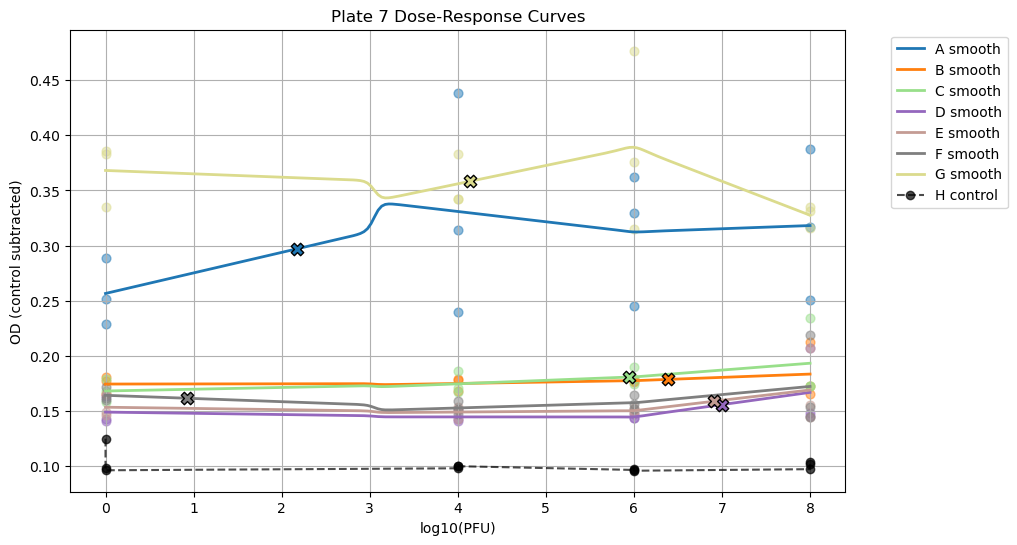

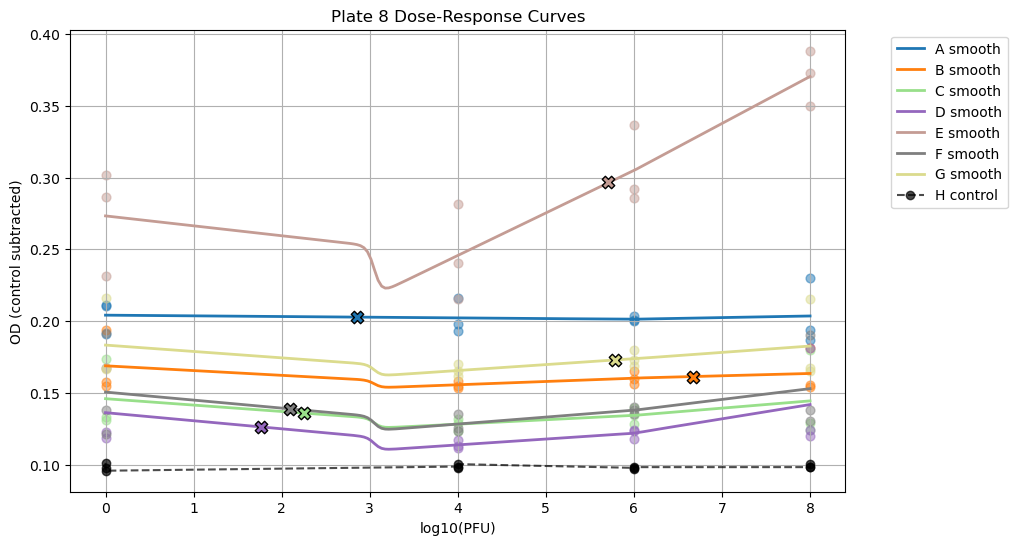

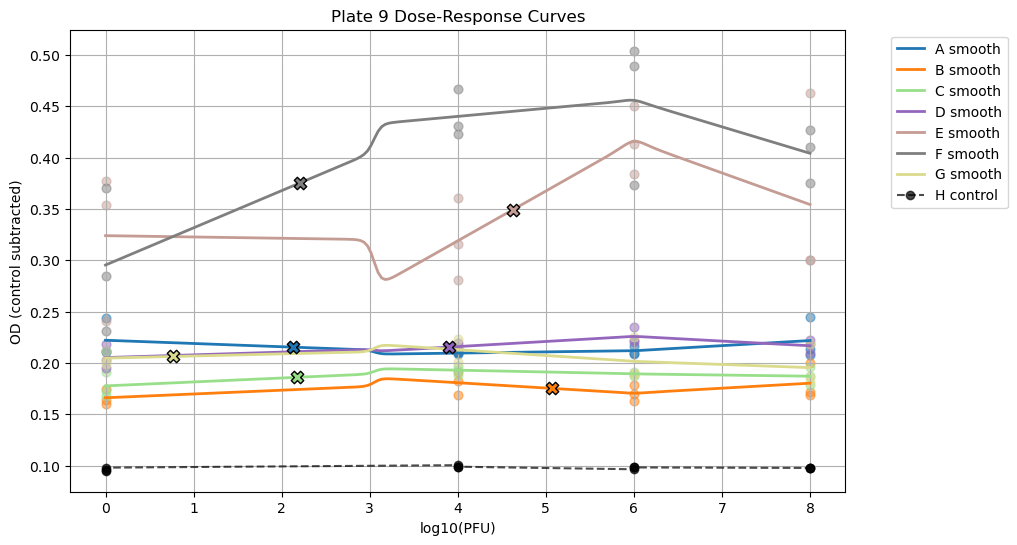

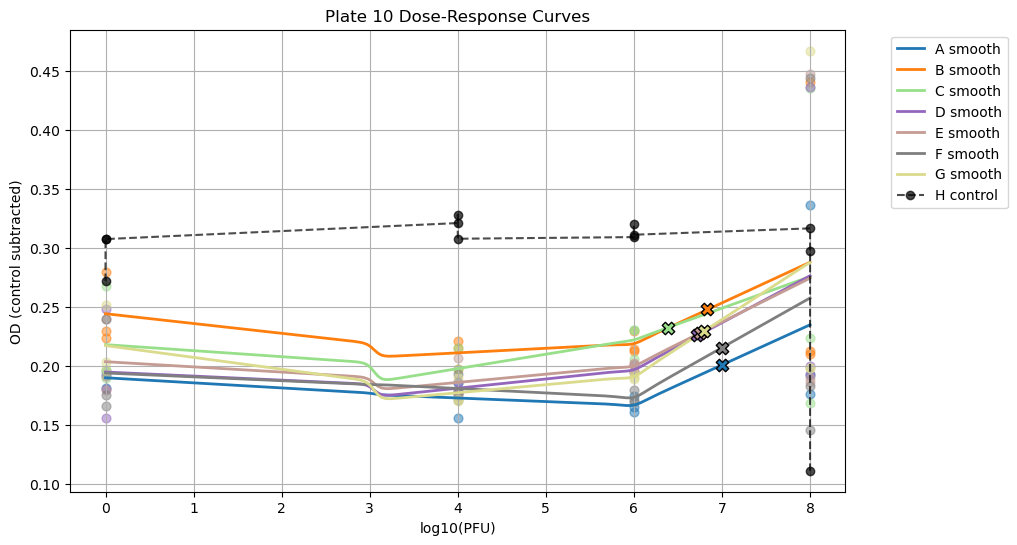

,A,B,C,D,E,F,G,H
1,5.052631e+04,9.884959e+06,1.625756e+02,3.292971e+07,1.431459e+07,9.329304e+01,2.354286e+02,NaN
2,4.198707e+04,6.669920e+04,7.488104e+06,9.884959e+06,3.072113e+01,3.072113e+01,1.382622e+04,NaN
3,2.833096e+02,1.084366e+07,1.023411e+02,4.198707e+04,2.196385e+04,9.221979e+00,4.297005e+06,NaN
4,4.768612e+07,6.826072e+06,6.222571e+06,3.331295e+00,1.464971e+01,3.370064e+01,9.884959e+06,NaN
5,9.884959e+06,2.967302e+06,2.097046e+00,1.217383e+01,8.406653e+00,2.523539e+00,2.523539e+00,NaN
6,1.231551e+02,2.494508e+07,1.625756e+02,2.002200e+04,1.625756e+02,2.552908e+01,1.625756e+02,NaN
7,1.482021e+02,2.465811e+06,8.907355e+05,9.884959e+06,8.214344e+06,8.406653e+00,1.382622e+04,NaN
8,7.149429e+02,4.713753e+06,1.783431e+02,5.872787e+01,5.111433e+05,1.231551e+02,6.150986e+05,NaN
9,1.350994e+02,1.162322e+05,1.482021e+02,7.934097e+03,4.198707e+04,1.625756e+02,5.805226e+00,NaN
10,9.884959e+06,6.826072e+06,2.465811e+06,5.170920e+06,5.672426e+06,9.884959e+06,6.222571e+06,NaN


In [202]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.nonparametric.kernel_regression import KernelReg

# Make sure Dose_plot is ready (small number for zero-dose)
tidy_all['Dose_plot'] = tidy_all['Dose'].replace(0, 0.01)

bio_reps = sorted(tidy_all['BioRep'].unique())
plates = sorted(tidy_all['Plate'].unique())

# Table to store IC50 values (control-subtracted)
ic50_table = pd.DataFrame(index=plates, columns=bio_reps, dtype=float)

for plate in plates:
    plate_df = tidy_all[tidy_all['Plate'] == plate]
    
    plt.figure(figsize=(10,6))
    plt.title(f'Plate {plate} Dose-Response Curves')
    
    # Extract control (BioRep H) for this plate
    control_df = plate_df[plate_df['BioRep']=='H'].set_index('Dose_plot')['OD']
    
    # Generate unique colors for each BioRep
    colors = plt.cm.tab20(np.linspace(0,1,len(bio_reps)))
    
    for i, bio in enumerate(bio_reps):
        bio_df = plate_df[plate_df['BioRep']==bio]
        x_vals = bio_df['Dose_plot'].values
        y_vals = bio_df['OD'].values

        if len(x_vals) == 0:
            continue

        if bio == 'H':
            # Plot control as dashed line
            plt.plot(np.log10(x_vals), y_vals, linestyle='--', marker='o', color='black', alpha=0.7, label='H control')
            continue

        # Subtract control OD
        y_corrected = y_vals - control_df.reindex(bio_df['Dose_plot'], fill_value=0).values

        # Log10 transform doses for smoothing
        x_log = np.log10(x_vals)
        
        # Kernel regression smoothing
        kr = KernelReg(endog=y_corrected, exog=x_log, var_type='c', reg_type='ll', bw=[0.5])
        x_grid = np.linspace(x_log.min(), x_log.max(), 200)
        y_smooth, _ = kr.fit(x_grid)
        
        # Half-max OD
        half_max = (y_smooth.max() + y_smooth.min()) / 2
        
        # Find IC50
        idx = np.argmin(np.abs(y_smooth - half_max))
        ic50_log = x_grid[idx]
        ic50 = 10**ic50_log
        ic50_table.loc[plate, bio] = ic50
        
        # Plot raw points (control-subtracted)
        plt.scatter(x_log, y_corrected, color=colors[i], alpha=0.5, s=40)
        
        # Plot smoothed curve
        plt.plot(x_grid, y_smooth, color=colors[i], lw=2, label=f'{bio} smooth')
        
        # Mark IC50 on the curve
        plt.scatter(ic50_log, half_max, color=colors[i], edgecolor='black', zorder=5, s=80, marker='X')

    plt.xlabel('log10(PFU)')
    plt.ylabel('OD (control subtracted)')
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05,1))
    plt.show()

# IC50 values table
ic50_table

In [203]:
ic50_values = ic50_table.values.flatten()

Text(0.5, 0, 'IC50 (PFU)')

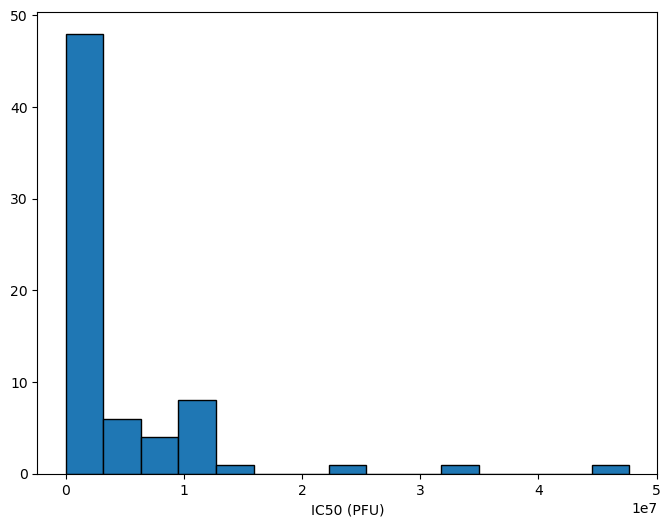

In [204]:
plt.figure(figsize=(8,6))
plt.hist(ic50_values, bins=15, edgecolor='black')
plt.xlabel('IC50 (PFU)')